# Trust-Drift — Complete Production System
## 02_train_model_final.ipynb

**Two-module architecture (fully modular, zero coupling):**

```
severity_scorer.py   ← signal generator   (AE + IF → severity + diagnostics)
trust_engine.py      ← decision layer     (severity → trust → zone → action)
```

**Full pipeline:**
```
Data → SeverityScorer ──severity_score──→ TrustDriftEngine → trust / zone / action
                      ──diagnostics──────→ Explainability Module (separate)
```

**What was fixed from previous versions:**

| # | Issue | Fix |
|---|-------|-----|
| 1 | Static 0.6/0.4 weights | Dynamic per-row: `w_ae = ae/(ae+if+ε)` |
| 2 | Min/max normalization | Percentile (1st/99th) — no gradient collapse |
| 3 | `score_row()` missing | Returns `(float, diagnostics_dict)` |
| 4 | Diagnostics dict format wrong | Exact spec with `weights` sub-dict |
| 5 | Squared feature error | `|x − x̂|` absolute (spec) |
| 6 | `get_verdict()` in signal layer | Removed — belongs in Explainability Module |
| 7 | `weight_ae/if` not stored | Stored per-row in `score_batch` |
| 8 | `ae_raw_score` missing | Added alongside `if_raw_score` |
| 9 | No EMA smoothing | Added in `score_dataset` (configurable alpha) |
| 10 | Trust Engine not integrated | Clean pipeline demo in Cell 8 |


## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Trust-Drift modules — place both .py files alongside this notebook
from severity_scorer import SeverityScorer
from trust_engine    import TrustDriftEngine, TrustState, Zone

print('TF:', tf.__version__)
print('All imports OK.')

TF: 2.20.0
All imports OK.


## 2. Configuration

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_PATH      = r'd:\Arfat\CyberCell\Trust_Drift\Trust_Drift_PoC\trust_drift'
MONDAY_PATH    = os.path.join(BASE_PATH, 'data', 'cleaned', 'monday_clean.csv')
TUESDAY_PATH   = os.path.join(BASE_PATH, 'data', 'cleaned', 'tuesday_clean.csv')
WEDNESDAY_PATH = os.path.join(BASE_PATH, 'data', 'cleaned', 'wednesday_clean.csv')
MODELS_PATH    = os.path.join(BASE_PATH, 'models')
RESULTS_PATH   = os.path.join(BASE_PATH, 'results')
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

LABEL_COL  = 'Label'
BENIGN_STR = 'BENIGN'

# Scorer config
TOP_N_FEATURES = 5
NORM_PCT_LOW   = 1
NORM_PCT_HIGH  = 99
EMA_ALPHA      = 0.3

# Trust Engine config
LAMBDA         = 1.5
MU             = 0.05
ANOMALY_THRESH = 0.5

print('Configuration loaded.')
print(f'  Normalization : [{NORM_PCT_LOW}th, {NORM_PCT_HIGH}th] percentile')
print(f'  EMA alpha     : {EMA_ALPHA}')
print(f'  Trust Engine  : lambda={LAMBDA}, mu={MU}, threshold={ANOMALY_THRESH}')

Configuration loaded.
  Normalization : [1th, 99th] percentile
  EMA alpha     : 0.3
  Trust Engine  : lambda=1.5, mu=0.05, threshold=0.5


## 3. Load and Preprocess

In [5]:
def load_df(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    if LABEL_COL not in df.columns:
        raise ValueError(f"'{LABEL_COL}' not found in {path}")
    df['binary_label'] = (
        df[LABEL_COL].astype(str).str.strip().str.upper() != BENIGN_STR
    ).astype(int)
    return df

def clean_features(df):
    X = df.drop(columns=[LABEL_COL, 'binary_label'], errors='ignore').copy()
    X = X.select_dtypes(include=[np.number]).copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    return X.fillna(X.median(numeric_only=True))

print('Loading ...')
df_mon = load_df(MONDAY_PATH)
df_tue = load_df(TUESDAY_PATH)
df_wed = load_df(WEDNESDAY_PATH)

X_mon_raw = clean_features(df_mon)
X_tue_raw = clean_features(df_tue)
X_wed_raw = clean_features(df_wed)

y_mon = df_mon['binary_label'].values
y_tue = df_tue['binary_label'].values
y_wed = df_wed['binary_label'].values
attack_type_tue = df_tue[LABEL_COL].astype(str).str.strip().values
attack_type_wed = df_wed[LABEL_COL].astype(str).str.strip().values

feature_cols = X_mon_raw.columns.tolist()
X_tue_raw = X_tue_raw.reindex(columns=feature_cols, fill_value=0)
X_wed_raw = X_wed_raw.reindex(columns=feature_cols, fill_value=0)

scaler = MinMaxScaler()
scaler.fit(X_mon_raw)
X_mon = scaler.transform(X_mon_raw)
X_tue = scaler.transform(X_tue_raw)
X_wed = scaler.transform(X_wed_raw)
X_train = X_mon[y_mon == 0]

for name, df_, y_ in [('Monday', df_mon, y_mon), ('Tuesday', df_tue, y_tue), ('Wednesday', df_wed, y_wed)]:
    print(f'{name:12} rows={len(df_):>8,}  attacks={y_.sum():>6,}  ratio={y_.mean():.4f}')
print(f'\nFeatures: {X_mon.shape[1]}   Training rows: {X_train.shape[0]:,}  (Monday benign)')

Loading ...
Monday       rows= 529,481  attacks=     0  ratio=0.0000
Tuesday      rows= 445,645  attacks=13,832  ratio=0.0310
Wednesday    rows= 691,406  attacks=251,723  ratio=0.3641

Features: 78   Training rows: 529,481  (Monday benign)


## 4. Train Autoencoder

Architecture: `Input(n) → 64 → 32 → 16 (bottleneck) → 32 → 64 → Output(n)`

Trained on Monday benign only. Attacks fail to compress through the
16-dim bottleneck → high reconstruction error → high AE severity.


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,390 (60.12 KB)

 Trainable params: 15,390 (60.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0121 - val_loss: 0.0011
Epoch 2/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.7377e-04 - val_loss: 9.4667e-04
Epoch 3/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.5412e-04 - val_loss: 9.1204e-04
Epoch 4/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.0656e-04 - val_loss: 8.9994e-04
Epoch 5/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.7864e-04 - val_loss: 8.8969e-04
Epoch 6/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6311e-04 - val_loss: 8.8525e-04
Epoch 7/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.5462e-04 - val_loss: 8.8397e-04
Epoch 8/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4917e-04 - val_loss: 8.8125e-04
Epoch 9/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4464e-04 - val_loss: 8.7799e-04
Epoch 10/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4074e-04 - val_loss: 8.7578e-04
Epoch 11/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.3389

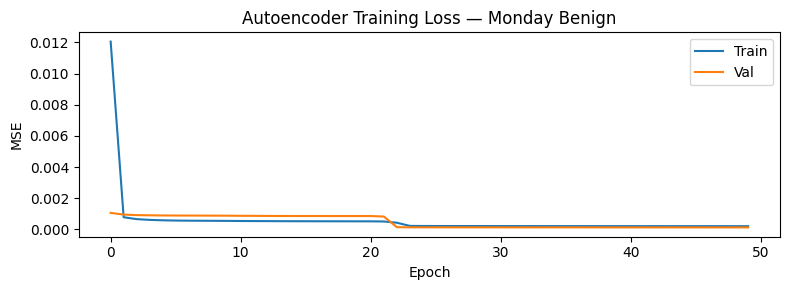

AE training complete.


In [6]:
INPUT_DIM = X_train.shape[1]

inp        = Input(shape=(INPUT_DIM,), name='input')
enc1       = Dense(64, activation='relu', name='encoder_1')(inp)
enc2       = Dense(32, activation='relu', name='encoder_2')(enc1)
bottleneck = Dense(16, activation='relu', name='bottleneck')(enc2)
dec1       = Dense(32, activation='relu', name='decoder_1')(bottleneck)
dec2       = Dense(64, activation='relu', name='decoder_2')(dec1)
output     = Dense(INPUT_DIM, activation='sigmoid', name='output')(dec2)

autoencoder   = Model(inputs=inp, outputs=output,     name='Autoencoder')
encoder_model = Model(inputs=inp, outputs=bottleneck, name='Encoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history = autoencoder.fit(
    X_train, X_train, epochs=50, batch_size=512,
    validation_split=0.1, shuffle=True, callbacks=[es], verbose=1
)

plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Autoencoder Training Loss — Monday Benign')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'ae_training_loss.png'), dpi=150)
plt.show()
print('AE training complete.')

## 5. Train Isolation Forest

In [7]:
iso_forest = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_train)
print('Isolation Forest fitted on Monday benign data.')

Isolation Forest fitted on Monday benign data.


## 6. Build and Calibrate SeverityScorer

`SeverityScorer` lives in `severity_scorer.py` — a standalone module
with no dependency on the Trust Engine.


In [8]:
scorer = SeverityScorer(
    autoencoder   = autoencoder,
    encoder_model = encoder_model,
    iso_forest    = iso_forest,
    scaler        = scaler,
    feature_names = feature_cols,
    top_n         = TOP_N_FEATURES,
    norm_pct_low  = NORM_PCT_LOW,
    norm_pct_high = NORM_PCT_HIGH,
    ema_alpha     = EMA_ALPHA,
)
scorer.calibrate(X_train)    # benign-only rows — NOT all of Monday
print(scorer)

[SeverityScorer] Calibrating on 529,481 benign rows ...
  Percentile anchors : [1th, 99th]
  AE MSE  p1/p99 : 0.000000 / 0.003649
  IF raw  p1/p99 : 0.321122 / 0.636994
  Calibration complete.

SeverityScorer(features=78, top_n=5, pct=[1,99], ema_alpha=0.3, calibrated=True)


## 7. score_row() — API Verification

Verify the single-row API returns the exact spec diagnostics dict format
and that `severity_score ∈ [0, 1]` is directly passable to `TrustDriftEngine.update()`.


In [9]:
severity_score, diag = scorer.score_row(X_train[0])

print('score_row() output:')
print(f'  severity_score  : {severity_score:.6f}')
print(f'  ae_score        : {diag["ae_score"]:.6f}')
print(f'  if_score        : {diag["if_score"]:.6f}')
print(f'  weights.ae      : {diag["weights"]["ae"]:.6f}')
print(f'  weights.if      : {diag["weights"]["if"]:.6f}')
print(f'  top_features    : {diag["top_features"]}')
print(f'  feature_errors  : [{", ".join(f"{e:.4f}" for e in diag["feature_errors"][:5])} ...]')
print(f'  (total feature_errors: {len(diag["feature_errors"])})')

# Invariant checks
assert 0.0 <= severity_score <= 1.0
assert abs(diag["weights"]["ae"] + diag["weights"]["if"] - 1.0) < 1e-4
assert len(diag["feature_errors"]) == len(feature_cols)
assert len(diag["top_features"])   == TOP_N_FEATURES
expected = {"severity_score","ae_score","if_score","weights","top_features","feature_errors"}
assert expected == set(diag.keys()), f"Missing keys: {expected - set(diag.keys())}"

print('\n✅ All assertions passed. score_row() API is correct.')

score_row() output:
  severity_score  : 0.137800
  ae_score        : 0.006368
  if_score        : 0.143627
  weights.ae      : 0.042453
  weights.if      : 0.957547
  top_features    : ['Destination Port', 'Bwd Packets/s', 'Fwd Packets/s', 'Flow Packets/s', 'Down/Up Ratio']
  feature_errors  : [0.0288, 0.0005, 0.0000, 0.0000, 0.0000 ...]
  (total feature_errors: 78)

✅ All assertions passed. score_row() API is correct.


## 8. Trust Engine Integration

`TrustDriftEngine` lives in `trust_engine.py` — completely independent
of the scorer, zero ML dependencies.

**Interface boundary (the only coupling that exists):**
```python
severity, diag = scorer.score_row(x)          # signal layer
state = engine.update_full(severity)           # decision layer
```

No shared state. No shared imports. Each module is independently deployable.


In [10]:
engine = TrustDriftEngine(
    lambda_           = LAMBDA,
    mu                = MU,
    anomaly_threshold = ANOMALY_THRESH,
    initial_trust     = 1.0,
)
print(engine)
print()

# 5 benign → 1 real attack → 4 recovery
test_rows = np.vstack([X_train[:5], X_tue[y_tue==1][:1], X_train[5:9]])
labels    = ['benign']*5 + ['ATTACK'] + ['recover']*4

print(f'{"#":>3}  {"label":<8}  {"severity":>9}  {"trust":>7}  zone  w_ae   w_if   action')
print('─' * 78)

for i, (x, label) in enumerate(zip(test_rows, labels)):
    severity, diag = scorer.score_row(x)                 # ← signal layer
    state = engine.update_full(severity)                  # ← decision layer

    print(
        f'{i:>3}  {label:<8}  {severity:>9.4f}  '
        f'{state.trust:>7.4f}  {state.zone.value:>4}  '
        f'{diag["weights"]["ae"]:>5.3f}  {diag["weights"]["if"]:>5.3f}  '
        f'{state.action}'
    )

print('\n✅ Pipeline verified. Modules are independent and compatible.')

TrustDriftEngine(trust=1.0000, zone=A, λ=1.5, μ=0.05, threshold=0.5)

  #  label      severity    trust  zone  w_ae   w_if   action
──────────────────────────────────────────────────────────────────────────────
  0  benign       0.1378   1.0000     A  0.042  0.958  Full network access granted
  1  benign       0.2931   1.0000     A  0.012  0.988  Full network access granted
  2  benign       0.2931   1.0000     A  0.012  0.988  Full network access granted
  3  benign       0.2931   1.0000     A  0.012  0.988  Full network access granted
  4  benign       0.1455   1.0000     A  0.061  0.939  Full network access granted
  5  ATTACK       0.5837   0.4166     B  0.799  0.201  Step-up MFA + session throttling
  6  recover      0.2936   0.4666     B  0.012  0.988  Step-up MFA + session throttling
  7  recover      0.2936   0.5166     B  0.012  0.988  Step-up MFA + session throttling
  8  recover      0.2936   0.5666     B  0.012  0.988  Step-up MFA + session throttling
  9  recover      0.12

## 9. Score Tuesday and Wednesday

In [11]:
df_tue_out = scorer.score_dataset(X_tue, y_tue, attack_type_tue, 'Tuesday')
df_wed_out = scorer.score_dataset(X_wed, y_wed, attack_type_wed, 'Wednesday')

print(f'Tuesday scored   : {len(df_tue_out):,} rows')
print(f'Wednesday scored : {len(df_wed_out):,} rows')
display_cols = [c for c in df_tue_out.columns if not c.startswith('feat_err_')]
print(f'\nOutput columns: {display_cols}')

[SeverityScorer] Scoring Tuesday (445,645 rows) ...
  445,645 / 445,645  (100.0%)
[SeverityScorer] Scoring Wednesday (691,406 rows) ...
  691,406 / 691,406  (100.0%)
Tuesday scored   : 445,645 rows
Wednesday scored : 691,406 rows

Output columns: ['flow_index', 'true_label', 'attack_type', 'ae_severity', 'if_severity', 'ae_raw_score', 'if_raw_score', 'weight_ae', 'weight_if', 'combined_severity', 'explain_driver', 'top_feature_1', 'top_error_1', 'top_feature_2', 'top_error_2', 'top_feature_3', 'top_error_3', 'top_feature_4', 'top_error_4', 'top_feature_5', 'top_error_5', 'severity_raw']


## 10. Evaluate

In [12]:
def evaluate(df_out, name):
    y_true   = df_out['true_label'].values
    combined = df_out['combined_severity'].values
    raw      = df_out['severity_raw'].values
    print(f'\n{"="*58}')
    print(f'  {name}')
    print(f'{"="*58}')
    if y_true.sum() == 0:
        print('  No attack rows.'); return
    print(f'  ROC-AUC (smoothed) : {roc_auc_score(y_true, combined):.4f}')
    print(f'  ROC-AUC (raw)      : {roc_auc_score(y_true, raw):.4f}')
    print(f'  Avg-Precision      : {average_precision_score(y_true, combined):.4f}')
    atk = df_out[df_out['true_label']==1]
    print(f'\n  Driver breakdown:')
    for d, cnt in atk['explain_driver'].value_counts().items():
        print(f'    {d}: {cnt:>6,} ({cnt/len(atk)*100:.1f}%)')
    print(f'\n  Top anomalous features:')
    for feat, cnt in atk['top_feature_1'].value_counts().head(5).items():
        print(f'    {feat:<40} → {cnt:>6,} rows')

evaluate(df_tue_out, 'Tuesday')
evaluate(df_wed_out, 'Wednesday')


  Tuesday
  ROC-AUC (smoothed) : 0.5900
  ROC-AUC (raw)      : 0.6460
  Avg-Precision      : 0.0339

  Driver breakdown:
    IF: 13,831 (100.0%)
    AE:      1 (0.0%)

  Top anomalous features:
    Destination Port                         →  6,789 rows
    Bwd IAT Total                            →  3,972 rows
    Fwd IAT Total                            →  2,933 rows
    Fwd Packets/s                            →     82 rows
    Packet Length Std                        →     21 rows

  Wednesday
  ROC-AUC (smoothed) : 0.8050
  ROC-AUC (raw)      : 0.8349
  Avg-Precision      : 0.8032

  Driver breakdown:
    AE: 126,711 (50.3%)
    IF: 125,012 (49.7%)

  Top anomalous features:
    Bwd Packet Length Std                    → 77,057 rows
    Destination Port                         → 71,878 rows
    FIN Flag Count                           → 50,326 rows
    ACK Flag Count                           → 27,890 rows
    Max Packet Length                        →  3,839 rows


## 11. Visualise Severity Distributions

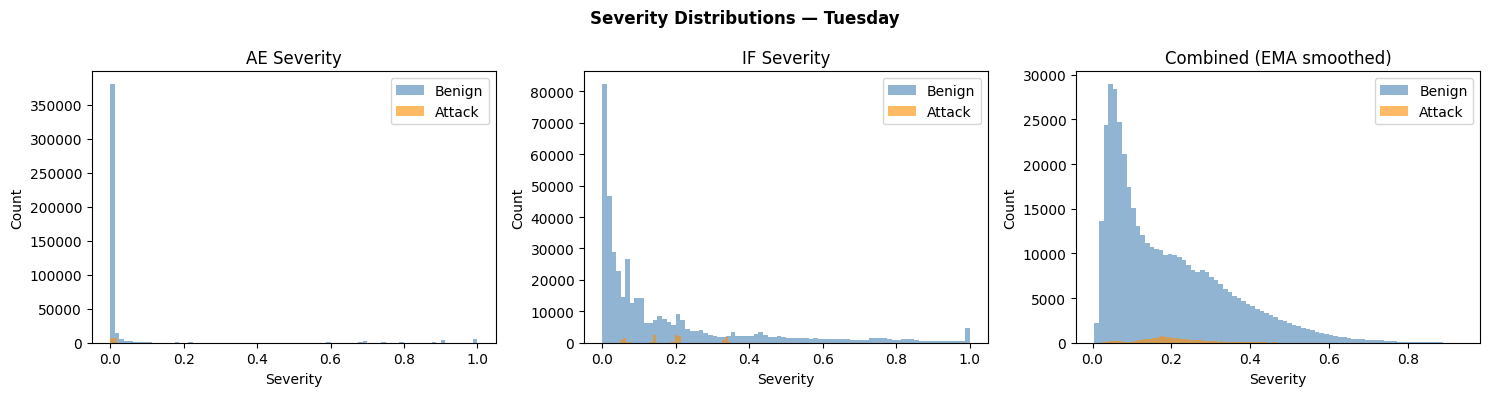

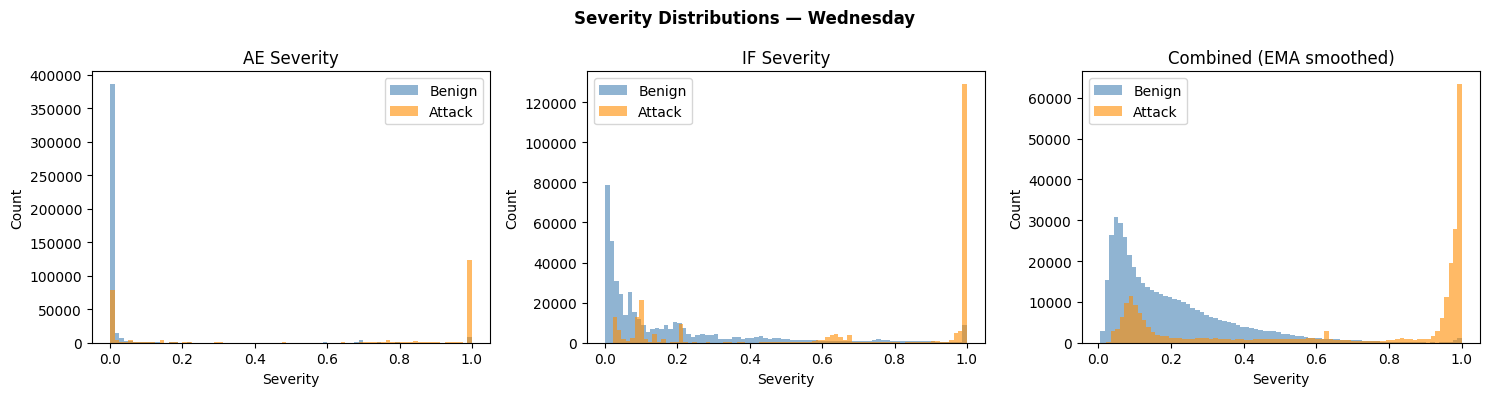

In [13]:
def plot_distribution(df_out, name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Severity Distributions — {name}', fontweight='bold')
    for ax, col, title in zip(
        axes,
        ['ae_severity', 'if_severity', 'combined_severity'],
        ['AE Severity', 'IF Severity', 'Combined (EMA smoothed)']
    ):
        ax.hist(df_out.loc[df_out['true_label']==0, col], bins=80, alpha=0.6, label='Benign', color='steelblue')
        if df_out['true_label'].sum() > 0:
            ax.hist(df_out.loc[df_out['true_label']==1, col], bins=80, alpha=0.6, label='Attack', color='darkorange')
        ax.set_title(title); ax.set_xlabel('Severity'); ax.set_ylabel('Count'); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'severity_dist_{name.lower()}.png'), dpi=150)
    plt.show()

plot_distribution(df_tue_out, 'Tuesday')
plot_distribution(df_wed_out, 'Wednesday')

## 12. Trust Engine Simulation — Wednesday

Replay Wednesday severity scores through a fresh Trust Engine to show
how trust evolves across the scored flow sequence.


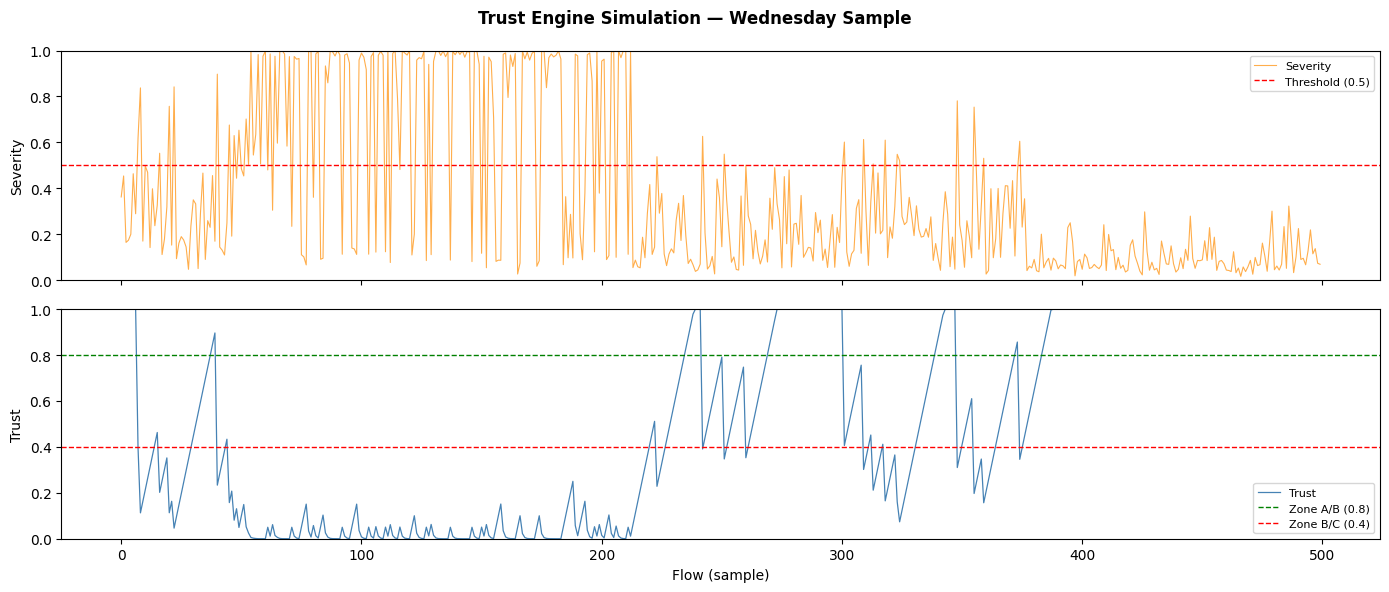

Zone distribution:
  Zone A:  175  (35.0%)
  Zone B:   85  (17.0%)
  Zone C:  240  (48.0%)


In [14]:
sim_engine = TrustDriftEngine(lambda_=LAMBDA, mu=MU, anomaly_threshold=ANOMALY_THRESH)
sample = df_wed_out.sample(min(500, len(df_wed_out)), random_state=42).sort_values('flow_index')

trust_trace, severity_trace, zone_trace = [], [], []
for _, row in sample.iterrows():
    sev   = float(row['combined_severity'])
    state = sim_engine.update_full(sev)
    severity_trace.append(sev)
    trust_trace.append(state.trust)
    zone_trace.append(state.zone.value)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('Trust Engine Simulation — Wednesday Sample', fontweight='bold')

ax1.plot(severity_trace, color='darkorange', alpha=0.7, linewidth=0.8, label='Severity')
ax1.axhline(ANOMALY_THRESH, color='red', linestyle='--', linewidth=1, label=f'Threshold ({ANOMALY_THRESH})')
ax1.set_ylabel('Severity'); ax1.legend(fontsize=8); ax1.set_ylim(0, 1)

ax2.plot(trust_trace, color='steelblue', linewidth=0.9, label='Trust')
ax2.axhline(0.8, color='green', linestyle='--', linewidth=1, label='Zone A/B (0.8)')
ax2.axhline(0.4, color='red',   linestyle='--', linewidth=1, label='Zone B/C (0.4)')
ax2.set_ylabel('Trust'); ax2.set_xlabel('Flow (sample)'); ax2.legend(fontsize=8); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'trust_simulation_wednesday.png'), dpi=150)
plt.show()

counts = pd.Series(zone_trace).value_counts()
print('Zone distribution:')
for z, cnt in sorted(counts.items()):
    print(f'  Zone {z}: {cnt:>4}  ({cnt/len(zone_trace)*100:.1f}%)')

## 13. Diagnostics Signal Sample

In [15]:
print('Diagnostics — Wednesday (highest severity row per attack type)')
print('=' * 72)

for attack_type in df_wed_out[df_wed_out['true_label']==1]['attack_type'].unique():
    subset = df_wed_out[
        (df_wed_out['true_label']==1) & (df_wed_out['attack_type']==attack_type)
    ].nlargest(1, 'combined_severity')
    if subset.empty: continue
    row = subset.iloc[0]
    print(f'\n  attack_type    : {attack_type}')
    print(f'  severity_score : {row["combined_severity"]:.4f}  (EMA smoothed)')
    print(f'  severity_raw   : {row["severity_raw"]:.4f}')
    print(f'  ae_score       : {row["ae_severity"]:.4f}   weight_ae={row["weight_ae"]:.3f}')
    print(f'  if_score       : {row["if_severity"]:.4f}   weight_if={row["weight_if"]:.3f}')
    print(f'  explain_driver : {row["explain_driver"]}')
    print(f'  top_features (|x - x_hat|):')
    for i in range(TOP_N_FEATURES):
        print(f'    [{i+1}] {row[f"top_feature_{i+1}"]:<38}  err={row[f"top_error_{i+1}"]:.6f}')

print('\nscore_row() diagnostics dict (exact spec format):')
x_atk = X_wed[df_wed_out['true_label'].values==1][0]
sev, diag = scorer.score_row(x_atk)
for k, v in diag.items():
    if k == 'feature_errors':
        print(f'  feature_errors  : [{", ".join(f"{e:.4f}" for e in v[:5])} ...  ({len(v)} total)]')
    else:
        print(f'  {k:<16}: {v}')

Diagnostics — Wednesday (highest severity row per attack type)

  attack_type    : DoS slowloris
  severity_score : 0.9844  (EMA smoothed)
  severity_raw   : 0.9864
  ae_score       : 1.0000   weight_ae=0.507
  if_score       : 0.9724   weight_if=0.493
  explain_driver : AE
  top_features (|x - x_hat|):
    [1] Bwd IAT Max                             err=0.263382
    [2] Bwd IAT Mean                            err=0.262864
    [3] Bwd IAT Min                             err=0.244606
    [4] Idle Std                                err=0.211358
    [5] Fwd IAT Mean                            err=0.142349

  attack_type    : DoS Slowhttptest
  severity_score : 0.9917  (EMA smoothed)
  severity_raw   : 1.0000
  ae_score       : 1.0000   weight_ae=0.500
  if_score       : 1.0000   weight_if=0.500
  explain_driver : AE
  top_features (|x - x_hat|):
    [1] Bwd IAT Mean                            err=0.276712
    [2] Idle Std                                err=0.249406
    [3] Bwd IAT Min    

## 14. Save Models and Scored CSVs

In [16]:
print('Saving models ...')
autoencoder.save(os.path.join(MODELS_PATH, 'autoencoder.keras'))
encoder_model.save(os.path.join(MODELS_PATH, 'encoder.keras'))
joblib.dump(iso_forest, os.path.join(MODELS_PATH, 'iso_forest.pkl'))
joblib.dump(scaler,     os.path.join(MODELS_PATH, 'scaler.pkl'))

calibration = {
    'ae_p_low':       scorer.ae_p_low,
    'ae_p_high':      scorer.ae_p_high,
    'if_p_low':       scorer.if_p_low,
    'if_p_high':      scorer.if_p_high,
    'feature_cols':   feature_cols,
    'top_n':          TOP_N_FEATURES,
    'norm_pct_low':   NORM_PCT_LOW,
    'norm_pct_high':  NORM_PCT_HIGH,
    'ema_alpha':      EMA_ALPHA,
    'engine_lambda':  LAMBDA,
    'engine_mu':      MU,
    'engine_threshold': ANOMALY_THRESH,
}
joblib.dump(calibration, os.path.join(MODELS_PATH, 'calibration.pkl'))

for f in sorted(os.listdir(MODELS_PATH)):
    full = os.path.join(MODELS_PATH, f)
    size = f'{os.path.getsize(full)/1024:.1f} KB' if os.path.isfile(full) else '[SavedModel dir]'
    print(f'  {f:<35} {size}')

df_tue_out.to_csv(os.path.join(RESULTS_PATH, 'severity_scores_tuesday.csv'),   index=False)
df_wed_out.to_csv(os.path.join(RESULTS_PATH, 'severity_scores_wednesday.csv'), index=False)


Saving models ...
  .gitkeep                            0.0 KB
  autoencoder.keras                   222.8 KB
  calibration.pkl                     1.7 KB
  encoder.keras                       50.2 KB
  iso_forest.pkl                      1454.3 KB
  scaler.pkl                          5.4 KB


In [17]:
# ================================
# SAVE FEATURE NAMES (VERY IMPORTANT)
# ================================

import joblib
import os

# ensure models folder exists
os.makedirs("models", exist_ok=True)

# Save feature column names
joblib.dump(feature_cols, "models/feature_cols.pkl")

print("feature_cols saved successfully ✅")
print("Number of features:", len(feature_cols))
print("Sample features:", feature_cols[:5])

feature_cols saved successfully ✅
Number of features: 78
Sample features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
